# Notebook 2: Data Cleaning & Exploratory Data Analysis

This notebook covers the **Data Cleaning & Preprocessing** pipeline:
1. Loading raw data and lookup tables (contractions, acronyms)
2. Pre-cleaning audit of the raw dataset
3. Text cleaning pipeline producing two output columns:
   - `light_clean_text` — lightly cleaned, preserves capitalisation and punctuation — for VADER sentiment and spaCy NER
   - `clean_text` — fully processed tokens — for BERTopic and TF-IDF
4. Exploratory Data Analysis with documented reasoning
5. Exporting the clean dataset for all downstream notebooks

## Section 1 — Install & Import Dependencies

Install and import the libraries used in this notebook.


In [1]:
!pip install pandas spacy matplotlib seaborn nltk wordcloud -q
!python -m spacy download en_core_web_sm -q


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('words', quiet=True)

from nltk.corpus import words as nltk_words
from nltk.util import ngrams
from wordcloud import WordCloud
from collections import Counter
from pathlib import Path
import spacy
from tqdm import tqdm

tqdm.pandas()
nlp = spacy.load('en_core_web_sm')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

Path('eda').mkdir(exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Section 2 — Load Data & Lookup Tables

Load the raw comments dataset and the two preprocessing lookup tables.


In [3]:
# ── Load comments ──────────────────────────────────────────────────────────
comments_df = pd.read_csv('comments.csv.gz')

print(f'Comments shape : {comments_df.shape}')
print()
print('── Comments columns ──')
print(comments_df.dtypes)
print()
print('── First 3 rows ──')
comments_df.head(3)

Comments shape : (56188, 7)

── Comments columns ──
comment_id        str
video_id          str
author            str
published_at      str
like_count      int64
text              str
title             str
dtype: object

── First 3 rows ──


,comment_id,video_id,author,published_at,like_count,text,title
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,@jadehannah916,2026-06-22T19:50:06Z,0,19:23 expiry dates have left the chat,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,@jadehannah916,2026-06-22T19:46:57Z,0,16:34 just work at a grocery store at this point,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,@Sevdalina-e2l,2026-06-22T11:08:51Z,0,19:40 this specific content made my heart blee...,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."


In [4]:
# ── Load contractions ──────────────────────────────────────────────────────
# Format: contraction:expansion
contractions_map = {}
with open('contractions.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if ':' in line:
            key, val = line.split(':', 1)
            contractions_map[key.lower().strip()] = val.lower().strip()

# Use straight apostrophes for matching.
contractions_map = {
    k.replace('’', "'").replace('‘', "'"): v
    for k, v in contractions_map.items()
}

# Match longer contractions first.
sorted_contractions = sorted(contractions_map.items(), key=lambda x: -len(x[0]))

print(f'Loaded {len(contractions_map)} contractions.')


Loaded 125 contractions.


In [5]:
# ── Load acronyms ──────────────────────────────────────────────────────────
# Keep alphabetic abbreviations only.
acronym_df = pd.read_csv('acronyms.csv', header=0)
acronym_df.columns = ['abbr', 'expansion']
acronym_df = acronym_df[acronym_df['abbr'].str.match(r'^[a-zA-Z]+$', na=False)]
acronym_df['abbr']      = acronym_df['abbr'].str.lower()
acronym_df['expansion'] = acronym_df['expansion'].str.lower()
acronym_map = dict(zip(acronym_df['abbr'], acronym_df['expansion']))

print(f'Loaded {len(acronym_map)} acronyms.')


Loaded 4541 acronyms.


## Section 3 — Pre-Cleaning Data Audit

Check the raw data before cleaning.

This section looks at:
- Missing values
- Duplicate comment IDs and duplicate text
- Very short comments
- Raw comment length


In [6]:
# ── Null and duplicate audit ───────────────────────────────────────────────
print('=== NULL VALUE AUDIT ===')
print(comments_df.isnull().sum())
print()

# ── Duplicate audit ────────────────────────────────────────────────────────
dup_ids  = comments_df.duplicated(subset='comment_id').sum()
dup_text = comments_df.duplicated(subset='text').sum()
print(f'Duplicate comment_ids : {dup_ids}')
print(f'Duplicate text values : {dup_text}')
print()

# ── Very short comments ────────────────────────────────────────────────────
comments_df['raw_char_count'] = comments_df['text'].astype(str).str.len()
very_short = (comments_df['raw_char_count'] < 10).sum()
print(f'Comments with < 10 characters : {very_short}')
print()

# ── Length distribution snapshot ───────────────────────────────────────────
print('=== RAW CHARACTER COUNT — DESCRIPTIVE STATS ===')
print(comments_df['raw_char_count'].describe().round(1))


=== NULL VALUE AUDIT ===
comment_id      0
video_id        0
author          0
published_at    0
like_count      0
text            5
title           0
dtype: int64

Duplicate comment_ids : 0
Duplicate text values : 252

Comments with < 10 characters : 457

=== RAW CHARACTER COUNT — DESCRIPTIVE STATS ===
count    56183.0
mean       238.5
std        307.1
min          1.0
25%         75.0
50%        149.0
75%        292.0
max       9478.0
Name: raw_char_count, dtype: float64


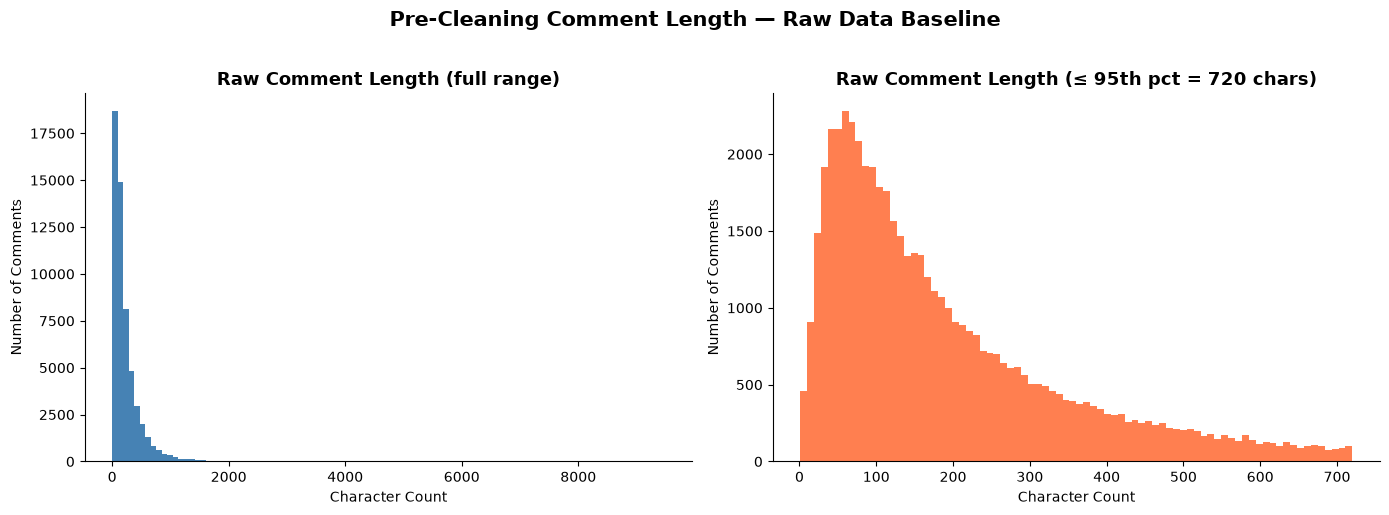

In [7]:
# ── Pre-cleaning character length distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(comments_df['raw_char_count'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Comment Length (full range)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Number of Comments')

p95 = comments_df['raw_char_count'].quantile(0.95)
axes[1].hist(
    comments_df[comments_df['raw_char_count'] <= p95]['raw_char_count'],
    bins=80, color='coral', edgecolor='none'
)
axes[1].set_title(f'Raw Comment Length (≤ 95th pct = {int(p95)} chars)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Number of Comments')

plt.suptitle('Pre-Cleaning Comment Length — Raw Data Baseline',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda/eda_01_raw_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 4 — Text Cleaning Pipeline

### Preprocessing Decision Log

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Drop null rows | Empty comments cannot be analysed |
| 2 | Drop duplicate text | Repeated comments can distort word and topic counts |
| 3 | Drop comments with < 3 raw words | Removes obvious junk before heavier cleaning |
| 4 | Create `light_clean_text` | Removes URLs, @handles, timestamps, and HTML entities while keeping casing and punctuation |
| 5 | Lowercase | Makes lookup matching more consistent |
| 6 | Apply domain overrides | Fixes project-specific cases before the acronym file runs |
| 7 | Expand acronyms | Expands useful shorthand while avoiding contractions, hyphenated words, and masked profanity |
| 8 | Expand contractions | Converts forms like `don't` to `do not` |
| 9 | Repeated-letter normalisation | Fixes elongated words only when the result is a known/protected word |
| 10 | spaCy tokenisation and lemmatisation | Converts words like `buying` and `influencers` to their base forms |
| 11 | Stopword and token filtering | Removes stopwords, punctuation, numbers, emojis, and very short tokens |
| 12 | Reconstruct `clean_text` | Joins the processed tokens for topic modelling and TF-IDF |
| 13 | Post-cleaning length filter | Removes comments with fewer than 3 clean tokens |



In [8]:
# ── Steps 1–3: Drop nulls, duplicates, very short raw comments ─────────────
df = comments_df.copy()

before = len(df)
df.dropna(subset=['text'], inplace=True)
df.drop_duplicates(subset='text', inplace=True)
after_dedup = len(df)
print(f'Dropped {before - after_dedup} rows (nulls + duplicate text)')

df['raw_word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df = df[df['raw_word_count'] >= 3].copy()
print(f'Dropped {after_dedup - len(df)} rows with < 3 raw words')
print(f'Remaining: {len(df):,} comments')


Dropped 253 rows (nulls + duplicate text)
Dropped 752 rows with < 3 raw words
Remaining: 55,183 comments


In [9]:
# ── Step 4: base_clean → light_clean_text ──────────────────────────────────
# Remove basic noise but keep casing and punctuation.

def base_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                      # @handles
    text = re.sub(r'\b\d{1,2}:\d{2}\b', '', text)         # timestamps
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', '', text)    # HTML entities
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Creating light_clean_text...')
df['light_clean_text'] = df['text'].progress_apply(base_clean)
print('light_clean_text created.')


Creating light_clean_text...


100%|██████████| 55183/55183 [00:00<00:00, 92966.59it/s]

light_clean_text created.


In [10]:
# ── Steps 5–8: Lowercase, overrides, acronyms, contractions ───────────────
# Produces norm_text, which is used to build clean_text.

DOMAIN_OVERRIDES = {
    'im': 'i am',
    'fyp': 'for you page',
    'abd': 'and',
    'yt': 'youtube',
    'xd': '',
    'bs': '',
    'af': ''
}

def apply_domain_overrides(text):
    text = str(text).replace('\u2019', "'").replace('\u2018', "'")
    text = re.sub(r'\btik[\s\-_/]+tok(s)?\b', r'tiktok\1', text)
    for key, value in DOMAIN_OVERRIDES.items():
        text = re.sub(r'\b' + re.escape(key) + r'\b', value, text)
    return text

def expand_acronyms(text):
    # Match standalone acronym tokens only.
    return re.sub(
        r"(?<![A-Za-z'’‘*-])[a-z]+(?![A-Za-z'’‘*-])",
        lambda match: acronym_map.get(match.group(0), match.group(0)),
        str(text)
    )

def expand_contractions(text):
    text = str(text).replace('\u2019', "'").replace('\u2018', "'")
    for contraction, expansion in sorted_contractions:
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
    return text


print('Lowercasing...')
df['norm_text'] = df['light_clean_text'].str.lower()

print('Applying domain-specific overrides...')
df['norm_text'] = df['norm_text'].progress_apply(apply_domain_overrides)

print('Expanding acronyms...')
df['norm_text'] = df['norm_text'].progress_apply(expand_acronyms)

print('Expanding contractions...')
df['norm_text'] = df['norm_text'].progress_apply(expand_contractions)

print('norm_text created.')


Lowercasing...
Applying domain-specific overrides...


100%|██████████| 55183/55183 [00:01<00:00, 52703.86it/s]


Expanding acronyms...


100%|██████████| 55183/55183 [00:00<00:00, 80891.41it/s]


Expanding contractions...


100%|██████████| 55183/55183 [00:15<00:00, 3571.15it/s]

norm_text created.


In [11]:
# ── Step 9: Repeated-letter normalisation setup ───────────────────────────
# Only normalise elongated words when the result is known.

WHITELIST = {
    'tiktok', 'youtube', 'instagram', 'restock', 'haul', 'skincare',
    'overconsumption', 'underconsumption', 'deinfluencing', 'influencer',
    'influencers', 'vlog', 'collab', 'grwm', 'ootd', 'sephora', 'ulta',
    'depop', 'shein', 'primark', 'zara', 'minimalism', 'minimalist',
    'consumerism', 'capitalism', 'asmr', 'fomo', 'stanley',
    'tiktoks', 'youtuber', 'youtubers',
}

correction_dictionary = {w.lower() for w in nltk_words.words() if w.isalpha()}

protected_terms = set(WHITELIST)
capitalized_counts = Counter()
for raw_text in df['light_clean_text'].dropna():
    for token in re.findall(r"\b[A-Z][A-Za-z]{2,}(?:'[sS])?\b", str(raw_text)):
        token_clean = re.sub(r'[^a-z]', '', token.lower())
        if token_clean:
            capitalized_counts[token_clean] += 1

entity_like_terms = {token for token, count in capitalized_counts.items() if count >= 2}
protected_terms.update(entity_like_terms)

protected_terms.update(acronym_map.keys())
for expansion in acronym_map.values():
    protected_terms.update(re.findall(r'\b[a-z]{2,}\b', str(expansion).lower()))


def is_known_or_protected(word):
    return word in correction_dictionary or word in protected_terms


def normalize_elongated_word(word):
    if len(word) <= 3 or word in protected_terms or word in correction_dictionary:
        return word

    # eeeeeverywhere -> everywhere
    one_char = re.sub(r'(.)\1{2,}', r'\1', word)
    if one_char != word and is_known_or_protected(one_char):
        return one_char

    # keep normal double letters when possible
    two_char = re.sub(r'(.)\1{2,}', r'\1\1', word)
    if two_char != word and is_known_or_protected(two_char):
        return two_char

    # wheree -> where
    if len(word) >= 5 and word[-1] == word[-2]:
        trimmed = word[:-1]
        if is_known_or_protected(trimmed):
            return trimmed

    return word


word_counts = Counter()
for text in tqdm(df['norm_text'], desc='Building vocabulary'):
    for raw_word in str(text).split():
        word = re.sub(r'[^a-z]', '', raw_word.lower())
        if word:
            word_counts[word] += 1

print(f'\nUnique words in vocabulary : {len(word_counts):,}')
print(f'Protected terms            : {len(protected_terms):,}')
print('Repeated-letter normalisation helpers ready.')


Building vocabulary: 100%|██████████| 55183/55183 [00:01<00:00, 44529.13it/s]


Unique words in vocabulary : 47,270
Protected terms            : 10,853
Repeated-letter normalisation helpers ready.


In [12]:
# ── Step 9: Apply repeated-letter normalisation ─────────────────────────────
# Save corrected words in spell_audit_df for review.

correction_map = {}
spell_audit_rows = []

for word, count in tqdm(word_counts.items(), desc='Building correction map'):
    normalized = normalize_elongated_word(word)
    if normalized != word:
        correction_map[word] = normalized
        spell_audit_rows.append({
            'original_word': word,
            'corrected_word': normalized,
            'count': count,
        })

spell_audit_df = pd.DataFrame(
    spell_audit_rows,
    columns=['original_word', 'corrected_word', 'count']
)
if not spell_audit_df.empty:
    spell_audit_df = spell_audit_df.sort_values('count', ascending=False).reset_index(drop=True)


def apply_corrections(text):
    words = str(text).split()
    corrected_words = []
    for raw_word in words:
        word_key = re.sub(r'[^a-z]', '', raw_word.lower())
        corrected_words.append(correction_map.get(word_key, raw_word))
    return ' '.join(corrected_words)

print('Applying repeated-letter normalisation...')
df['norm_text'] = df['norm_text'].progress_apply(apply_corrections)

print('\nRepeated-letter normalisation summary')
print(f'Unique vocabulary checked : {len(word_counts):,}')
print(f'Words normalised          : {len(correction_map):,}')

spell_audit_df.head(10)


Building correction map: 100%|██████████| 47270/47270 [00:00<00:00, 1089199.19it/s]


Applying repeated-letter normalisation...


100%|██████████| 55183/55183 [00:01<00:00, 54730.77it/s]


Repeated-letter normalisation summary
Unique vocabulary checked : 47,270
Words normalised          : 743


,original_word,corrected_word,count
0,wayyy,way,18
1,noooo,no,13
2,alllll,al,10
3,youll,youl,9
4,allllll,al,8
5,wastefull,wasteful,7
6,toooo,to,6
7,alll,al,6
8,harmfull,harmful,6
9,usefull,useful,6


In [13]:
# ── Steps 10–12: Custom stopwords and lemmatisation ───────────────────────
# Add project-specific stopwords before spaCy processing.

CUSTOM_STOPS = {
    'yeah', 'ok', 'okay', 'literally', 'actually', 'honestly',
    'video', 'watch', 'watching', 'channel',
    'got', 'come', 'look', 'said', 'feel', 'think', 'know',
    'lot', 'right', 'etc',
    'thing', 'things', 'way', 'time', 'people',
    'want', 'need'
}

for word in CUSTOM_STOPS:
    nlp.vocab[word].is_stop = True

print(f'Custom stopwords added: {len(CUSTOM_STOPS)}')


Custom stopwords added: 27


In [14]:
# ── spaCy batch processing ──────────────────────────────────────────────────
# Use nlp.pipe() because it is faster than processing rows one by one.


def extract_tokens(doc):
    return [
        token.lemma_
        for token in doc
        if not token.is_stop       # stopwords
        and not token.is_punct     # punctuation
        and not token.is_space     # whitespace
        and not token.like_num     # numbers
        and token.is_alpha         # letters only
        and len(token.text) > 1    # single-character tokens
    ]

texts = df['norm_text'].tolist()
docs  = list(tqdm(
    nlp.pipe(texts, disable=['ner', 'parser'], batch_size=64),
    total=len(texts),
    desc='spaCy lemmatisation'
))

df['tokens']     = [extract_tokens(doc) for doc in docs]
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))
df['word_count'] = df['tokens'].apply(len)
df['char_count'] = df['clean_text'].apply(len)

df['published_at']    = pd.to_datetime(df['published_at'], utc=True)
df['published_month'] = df['published_at'].dt.to_period('M')

print('Done.')


spaCy lemmatisation: 100%|██████████| 55183/55183 [02:22<00:00, 387.45it/s]


Done.


In [15]:
# ── Step 13: Post-cleaning length filter ────────────────────────────────────
# Remove comments with too few clean tokens.

df = df[df['clean_text'].str.strip().str.len() > 0].copy()

before_filter = len(df)
df = df[df['word_count'] >= 3].copy().reset_index(drop=True)
print(f'Dropped {before_filter - len(df)} rows with < 3 clean tokens')
print(f'Final dataset: {len(df):,} comments')


Dropped 3268 rows with < 3 clean tokens
Final dataset: 51,807 comments


In [16]:
# ── Final pipeline check ───────────────────────────────────────────────────
word_count_summary = df['word_count'].describe().round(1).to_frame('word_count')
display(word_count_summary)

sample_rows = df[['text', 'light_clean_text', 'clean_text']].sample(
    n=min(2, len(df)),
    random_state=None
)
for _, row in sample_rows.iterrows():
    orig  = str(row['text'])[:100]
    light = str(row['light_clean_text'])[:100]
    clean = str(row['clean_text'])[:100]
    print(f'  ORIGINAL    : {orig}')
    print(f'  LIGHT CLEAN : {light}')
    print(f'  CLEAN TEXT  : {clean}\n')


,word_count
count,51807.0
mean,18.0
std,22.1
min,3.0
25%,6.0
50%,12.0
75%,22.0
max,1122.0


  ORIGINAL    : Why even start with Dove sensitive when you're adding all those other products on top of it?
  LIGHT CLEAN : Why even start with Dove sensitive when you're adding all those other products on top of it?
  CLEAN TEXT  : start dove sensitive add product

  ORIGINAL    : Nah, that vegan friend can bring their own stuff. It's called being a guest at someone's house, it's
  LIGHT CLEAN : Nah, that vegan friend can bring their own stuff. It's called being a guest at someone's house, it's
  CLEAN TEXT  : vegan friend bring stuff call guest house fricke hotel consider have guest bathroom real essential l



---
## Section 5 — Exploratory Data Analysis (EDA)

Explore the cleaned dataset before downstream modelling.

### Plots in this section:
1. Comments per video
2. Clean comment length distribution
3. Average comment length by video
4. Likes distribution
5. Top 20 most-liked comments
6. Comment volume over time
7. Top 25 most active authors
8. Top 20 most frequent bigrams
9. Bigram word cloud


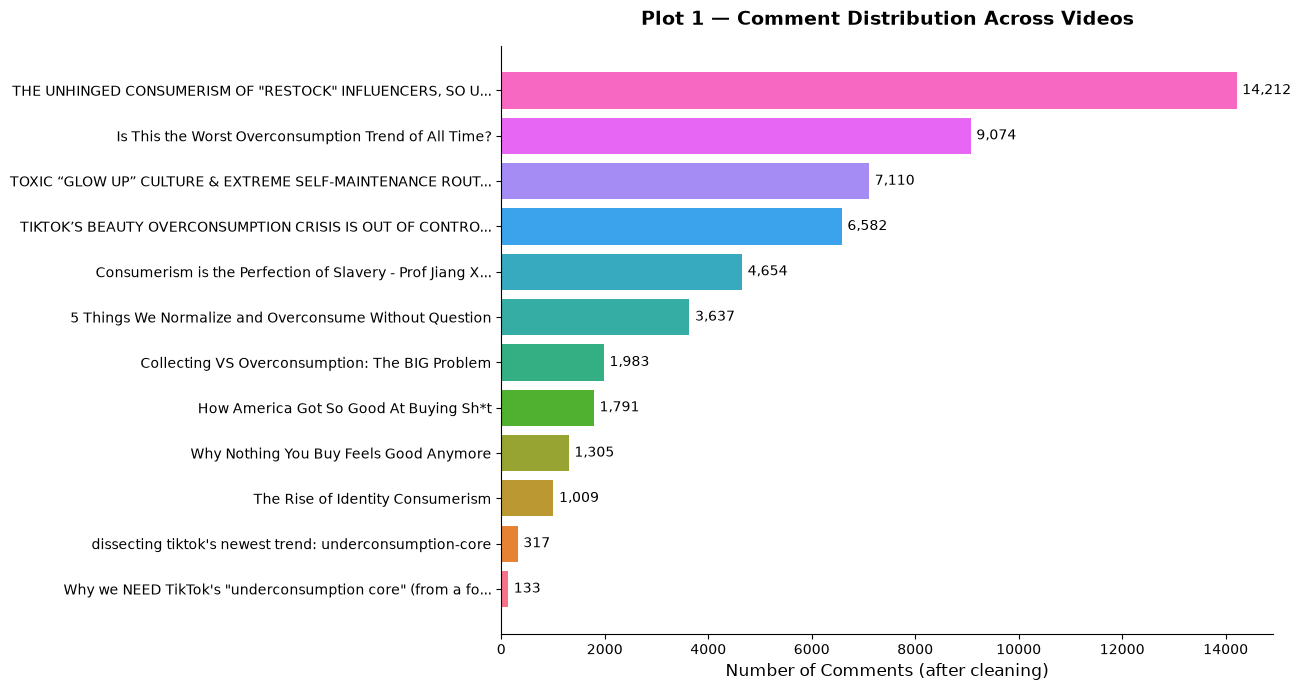

Top video share: 27.4%


In [17]:
# ── Plot 1: Comment distribution across videos ──────────────────────────────
# Checks whether one video dominates the dataset.

comment_counts = df.groupby('title')['comment_id'].count().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(
    [t[:55] + '...' if len(t) > 55 else t for t in comment_counts.index],
    comment_counts.values,
    color=sns.color_palette('husl', len(comment_counts))
)
ax.bar_label(bars, labels=[f'{v:,}' for v in comment_counts.values], padding=4, fontsize=10)
ax.set_xlabel('Number of Comments (after cleaning)', fontsize=12)
ax.set_title('Plot 1 — Comment Distribution Across Videos',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('eda/eda_02_comments_per_video.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top video share: {comment_counts.max() / comment_counts.sum() * 100:.1f}%')


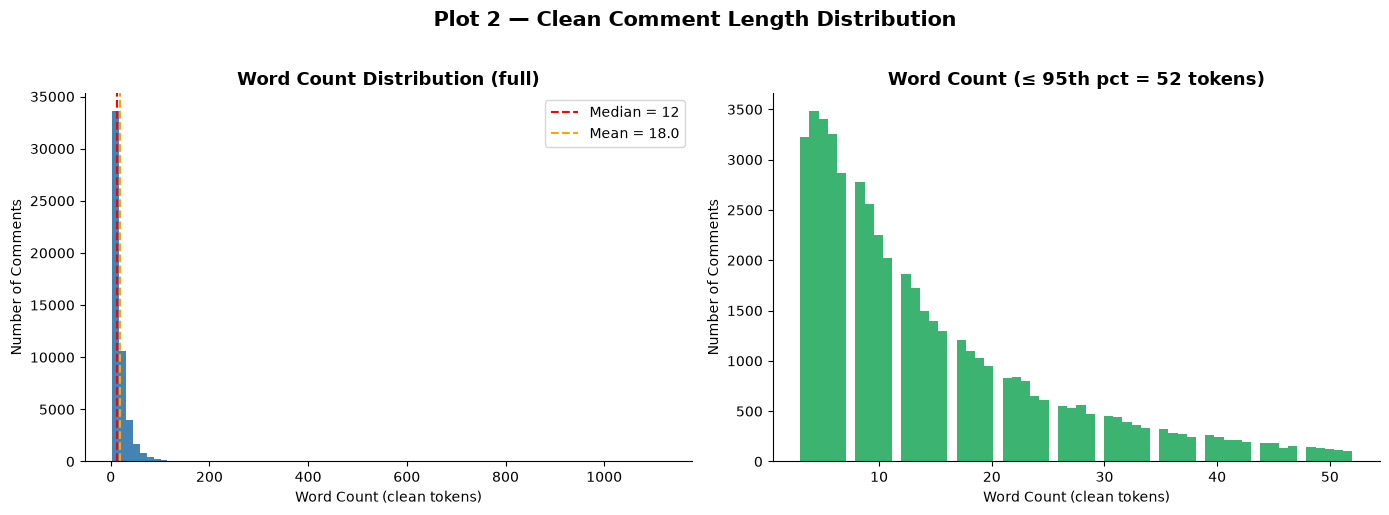

In [18]:
# ── Plot 2: Clean comment word count distribution ───────────────────────────
# Shows comment length after cleaning.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=80, color='steelblue', edgecolor='none')
median_wc = df['word_count'].median()
mean_wc   = df['word_count'].mean()
axes[0].axvline(median_wc, color='red',    linestyle='--', linewidth=1.5, label=f'Median = {median_wc:.0f}')
axes[0].axvline(mean_wc,   color='orange', linestyle='--', linewidth=1.5, label=f'Mean = {mean_wc:.1f}')
axes[0].set_title('Word Count Distribution (full)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (clean tokens)')
axes[0].set_ylabel('Number of Comments')
axes[0].legend()

p95 = df['word_count'].quantile(0.95)
axes[1].hist(df[df['word_count'] <= p95]['word_count'],
             bins=60, color='mediumseagreen', edgecolor='none')
axes[1].set_title(f'Word Count (≤ 95th pct = {int(p95)} tokens)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count (clean tokens)')
axes[1].set_ylabel('Number of Comments')

plt.suptitle('Plot 2 — Clean Comment Length Distribution',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda/eda_03_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


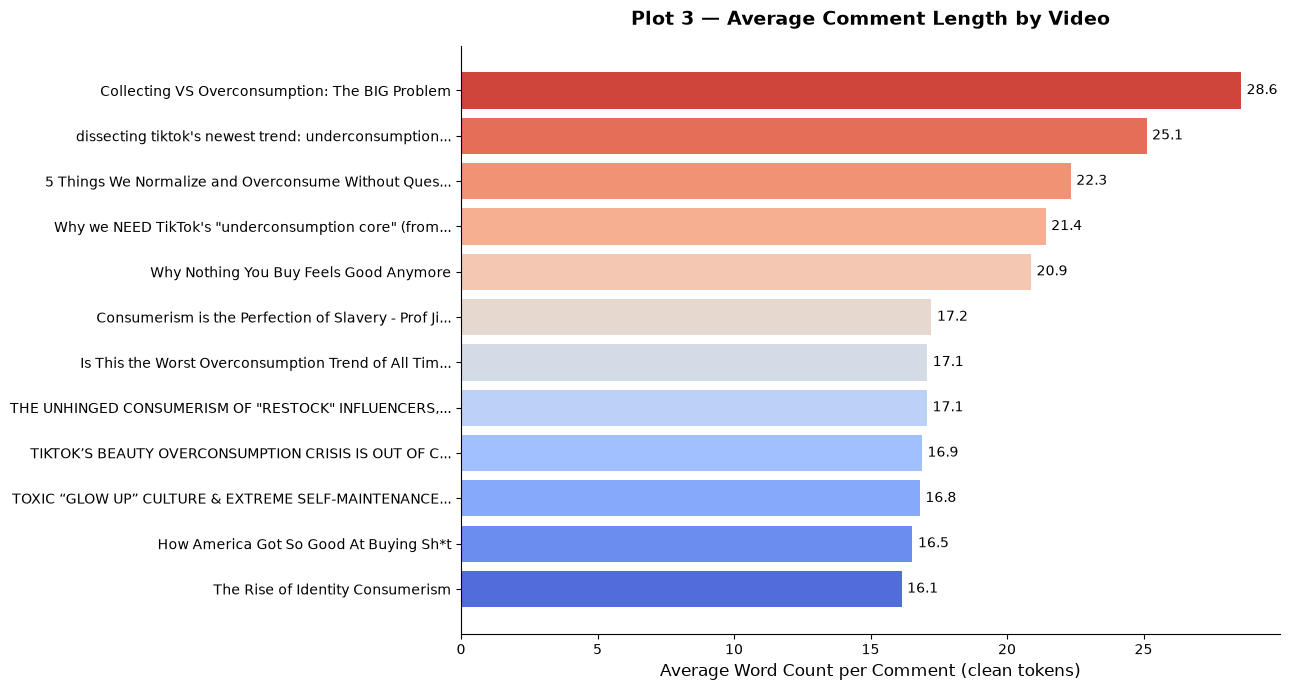

In [19]:
# ── Plot 3: Average word count per video ───────────────────────────────────
# Shows which videos received longer comments.

avg_length   = df.groupby('title')['word_count'].mean().sort_values(ascending=False)
short_titles = [t[:50] + '...' if len(t) > 50 else t for t in avg_length.index]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(short_titles[::-1], avg_length.values[::-1],
               color=sns.color_palette('coolwarm', len(avg_length)))
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
ax.set_xlabel('Average Word Count per Comment (clean tokens)', fontsize=12)
ax.set_title('Plot 3 — Average Comment Length by Video',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda/eda_04_avg_length_per_video.png', dpi=150, bbox_inches='tight')
plt.show()


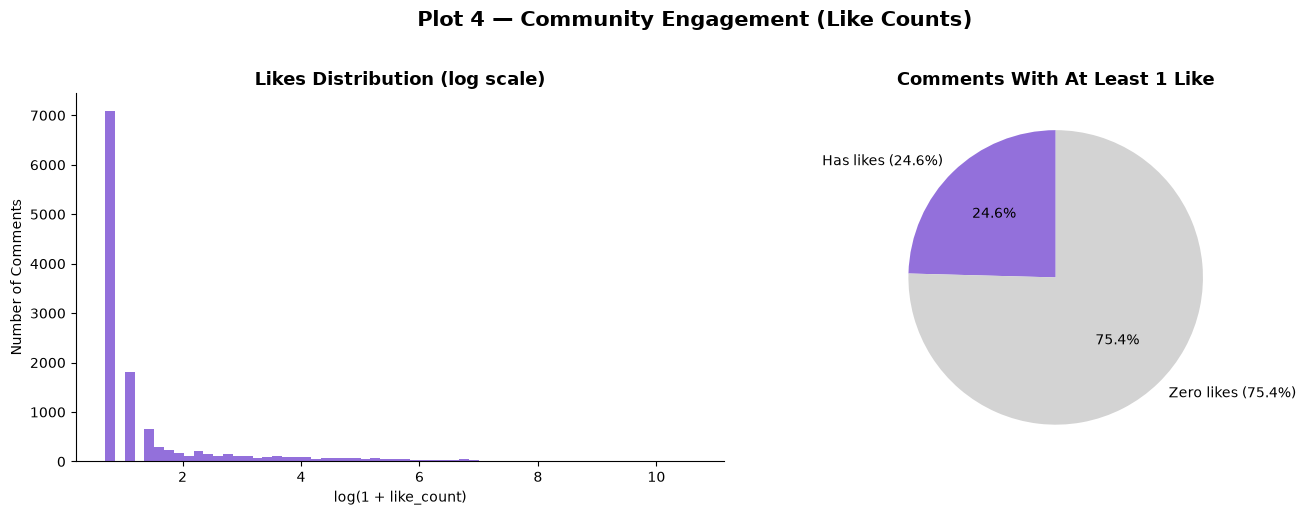

Max likes on a single comment: 42,107
Comments with > 100 likes    : 808


In [20]:
# ── Plot 4: Likes distribution ──────────────────────────────────────────────
# Shows how engagement is distributed across comments.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

likes_nonzero = df[df['like_count'] > 0]['like_count']
axes[0].hist(np.log1p(likes_nonzero), bins=60, color='mediumpurple', edgecolor='none')
axes[0].set_title('Likes Distribution (log scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log(1 + like_count)')
axes[0].set_ylabel('Number of Comments')

zero_pct = (df['like_count'] == 0).sum() / len(df) * 100
axes[1].pie(
    [100 - zero_pct, zero_pct],
    labels=[f'Has likes ({100 - zero_pct:.1f}%)', f'Zero likes ({zero_pct:.1f}%)'],
    colors=['mediumpurple', 'lightgrey'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Comments With At Least 1 Like', fontsize=13, fontweight='bold')

plt.suptitle('Plot 4 — Community Engagement (Like Counts)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda/eda_05_likes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Max likes on a single comment: {df["like_count"].max():,}')
print(f'Comments with > 100 likes    : {(df["like_count"] > 100).sum():,}')


In [21]:
# ── Plot 5: Top 20 most-liked comments ─────────────────────────────────────
# Prints highly-liked comments for manual review.

top_liked = (
    df[['author', 'title', 'like_count', 'text']]
    .sort_values('like_count', ascending=False)
    .head(20)
)

print('=== TOP 20 MOST-LIKED COMMENTS ===\n')
for _, row in top_liked.iterrows():
    title = str(row['title'])
    short_title = title[:45] + '...' if len(title) > 45 else title
    print(f"[{row['like_count']:,} likes] [{short_title}]")
    print(f"  {str(row['text'])[:180]}")
    print()


=== TOP 20 MOST-LIKED COMMENTS ===

[42,107 likes] [THE UNHINGED CONSUMERISM OF "RESTOCK" INFLUEN...]
  I grew up poor so I can definitively tell you I'm the target demographic for restock culture. They are targeting people who never want to feel the pain of not having enough again, 

[31,288 likes] [Consumerism is the Perfection of Slavery - Pr...]
  As long as people who make $50,000 a year vote for people who make $50,000 a day, the working class is doomed.

[28,920 likes] [Consumerism is the Perfection of Slavery - Pr...]
  “We buy things we don’t need… with money we don’t have… to impress people we don’t even like.”

[20,754 likes] [THE UNHINGED CONSUMERISM OF "RESTOCK" INFLUEN...]
  This is the clean version of hoarding

[20,299 likes] [THE UNHINGED CONSUMERISM OF "RESTOCK" INFLUEN...]
  I could never understand why one needs to label "grapes" on a clearly see-through container of grapes. I can see the grapes. They do not look like onions or anything else.

[20,174 likes] [Consum

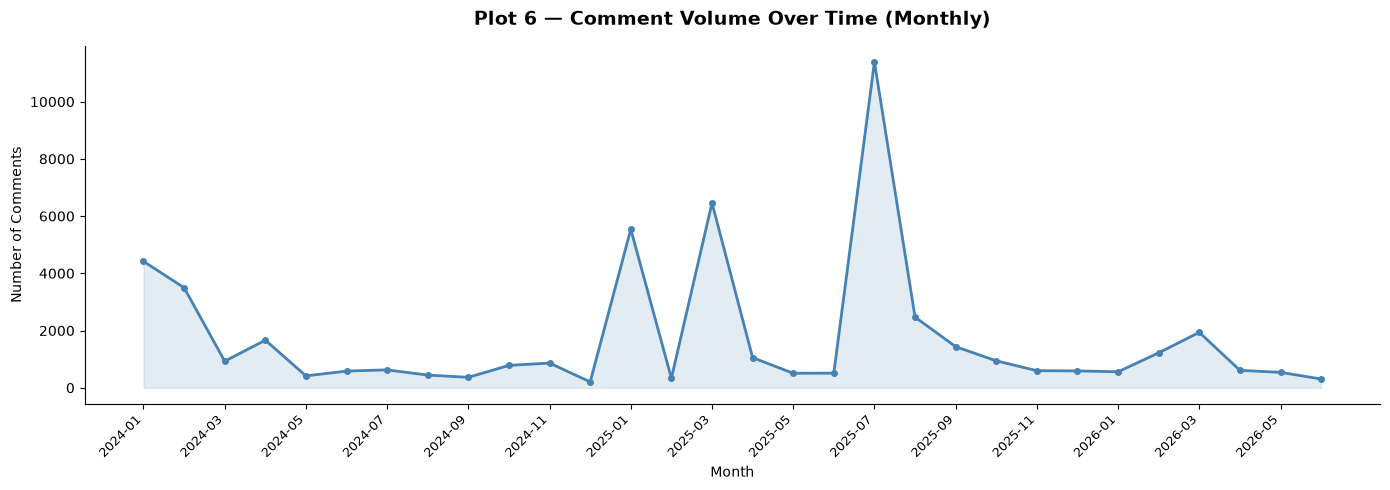

In [22]:
# ── Plot 6: Comment volume over time ───────────────────────────────────────
# Shows monthly comment volume.

monthly_counts = (
    df.groupby('published_month')['comment_id']
    .count()
    .reset_index()
)
monthly_counts['published_month'] = monthly_counts['published_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_counts['published_month'], monthly_counts['comment_id'],
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_counts['published_month'], monthly_counts['comment_id'],
                alpha=0.15, color='steelblue')
ax.set_title('Plot 6 — Comment Volume Over Time (Monthly)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Comments')

step = max(1, len(monthly_counts) // 12)
ax.set_xticks(range(0, len(monthly_counts), step))
ax.set_xticklabels(
    monthly_counts['published_month'].iloc[::step],
    rotation=45, ha='right', fontsize=9
)
plt.tight_layout()
plt.savefig('eda/eda_06_comments_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


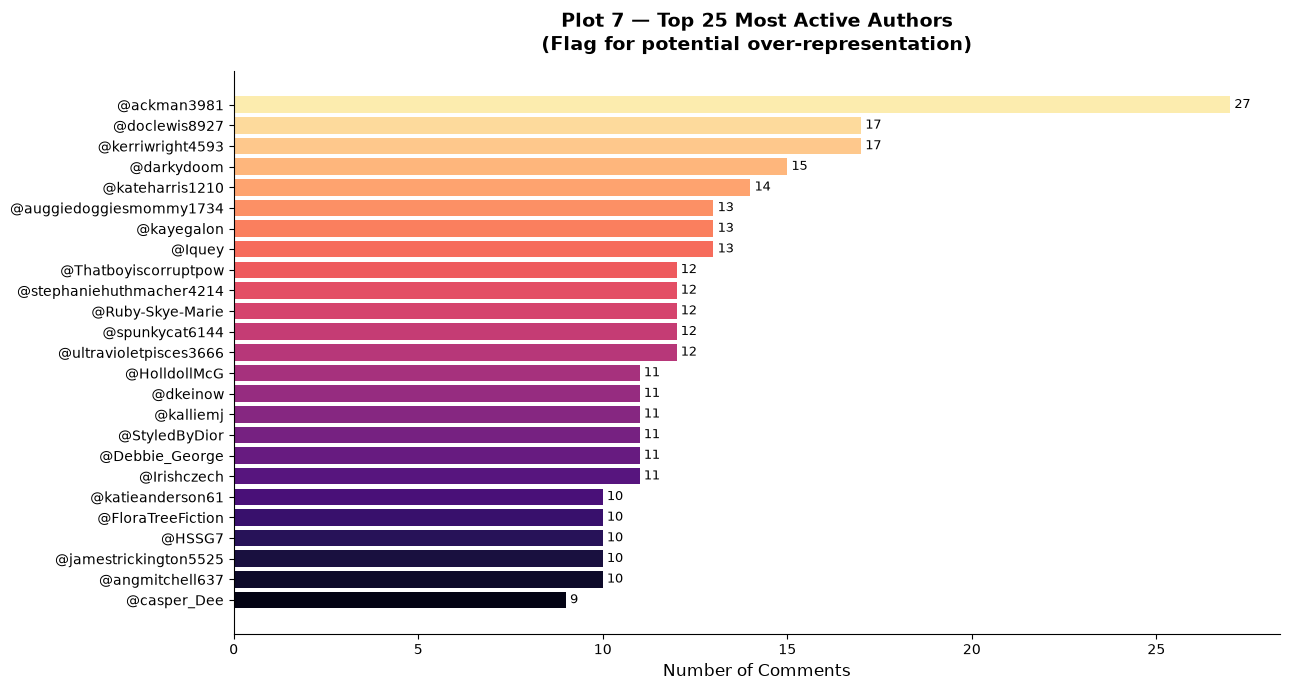

Unique authors               : 43,141
Top author comment count     : 27
Authors with > 10 comments   : 19
Authors with > 20 comments   : 1


In [23]:
# ── Plot 7: Top 25 most active authors ─────────────────────────────────────
# Checks whether a few authors dominate the comments.

author_counts = df.groupby('author')['comment_id'].count()
top_authors = author_counts.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=sns.color_palette('magma', len(top_authors)))
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel('Number of Comments', fontsize=12)
ax.set_title('Plot 7 — Top 25 Most Active Authors\n(Flag for potential over-representation)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda/eda_07_top_authors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unique authors               : {author_counts.shape[0]:,}')
print(f'Top author comment count     : {top_authors.iloc[0]}')
print(f'Authors with > 10 comments   : {(author_counts > 10).sum()}')
print(f'Authors with > 20 comments   : {(author_counts > 20).sum()}')


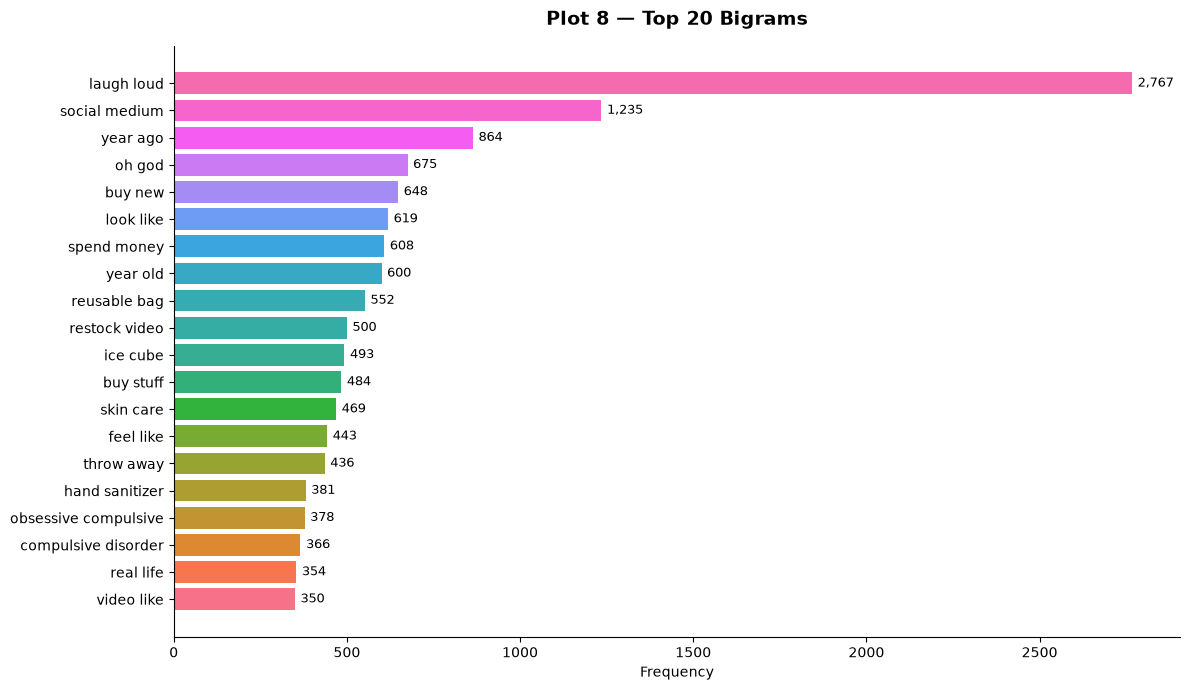

In [24]:
# ── Plot 8: Top 20 bigrams ─────────────────────────────────────────────────
# Shows common two-word phrases after cleaning.

def get_ngrams(corpus, n):
    all_ngrams = []
    for text in corpus:
        tokens = text.split()
        all_ngrams.extend(ngrams(tokens, n))
    return Counter(all_ngrams)

bigram_freq = get_ngrams(df['clean_text'], 2)
top_bigrams = bigram_freq.most_common(20)

fig, ax = plt.subplots(figsize=(12, 7))
labels = [' '.join(ng) for ng, _ in top_bigrams]
counts = [c for _, c in top_bigrams]
bars = ax.barh(labels[::-1], counts[::-1],
               color=sns.color_palette('husl', 20), edgecolor='none')
ax.bar_label(bars, labels=[f'{c:,}' for c in counts[::-1]], padding=4, fontsize=9)
ax.set_title('Plot 8 — Top 20 Bigrams', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Frequency')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('eda/eda_08_bigram_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


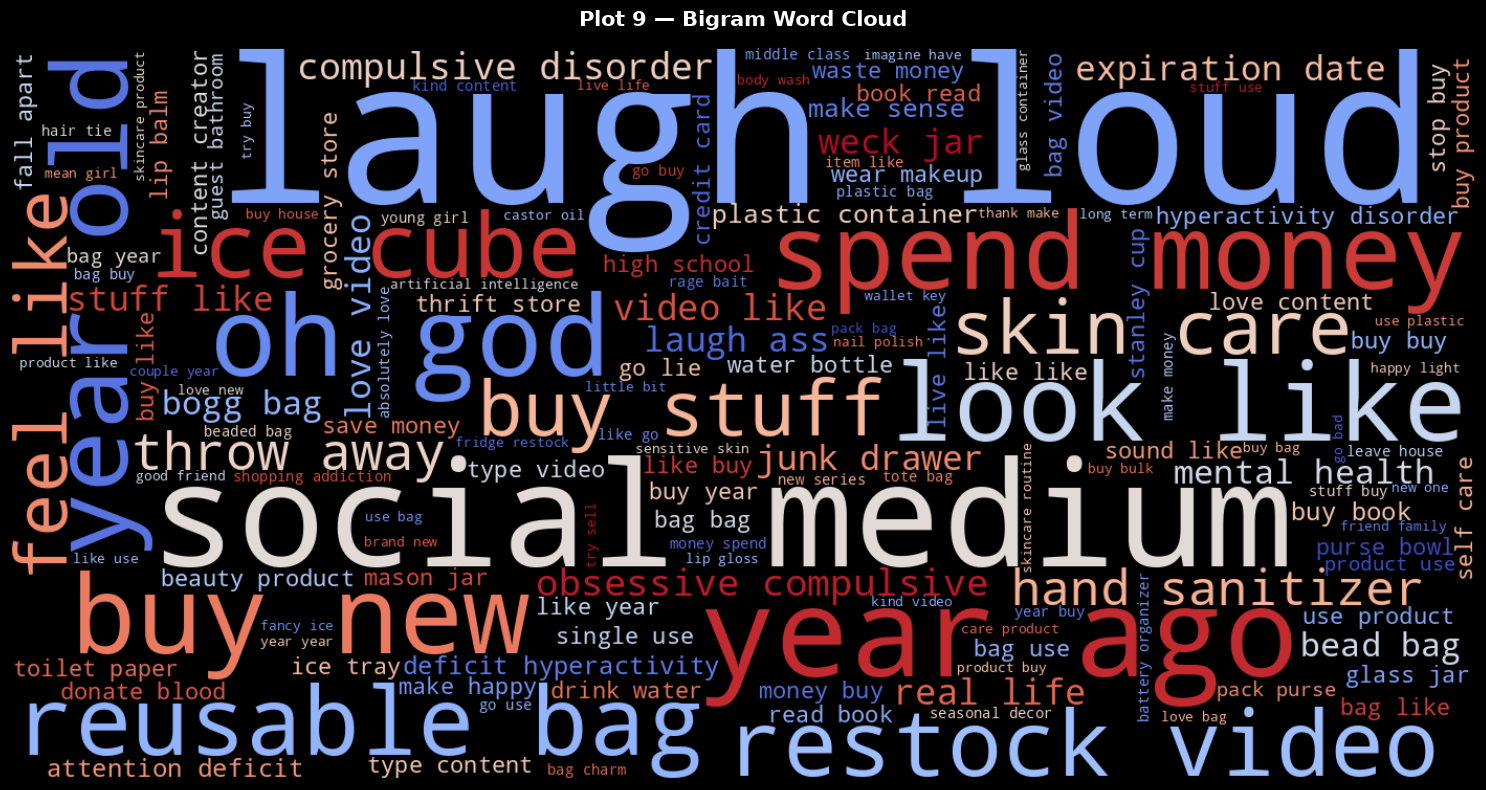

In [25]:
# ── Plot 9: Bigram word cloud ──────────────────────────────────────────────
# Visual summary of common bigrams.

bigram_display = {' '.join(bg): count for bg, count in bigram_freq.most_common(150)}

wordcloud = WordCloud(
    width=1400, height=700,
    background_color='black',
    colormap='coolwarm',
    max_words=150,
    collocations=False,
    prefer_horizontal=0.85
).generate_from_frequencies(bigram_display)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Plot 9 — Bigram Word Cloud', fontsize=15, fontweight='bold',
             pad=15, color='white')
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig('eda/eda_09_bigram_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()


## Section 6 — EDA Summary & Key Findings

Compute key statistics of cleaned data to summarise the EDA results.


In [26]:
# Compute summary values from the cleaned dataframe.

top_video     = df.groupby('title').size().sort_values(ascending=False)
deepest_video = df.groupby('title')['word_count'].mean().sort_values(ascending=False)
author_counts = df.groupby('author')['comment_id'].count()
top_bigram_labels = ', '.join([' '.join(bg) for bg, _ in top_bigrams[:6]]) if 'top_bigrams' in globals() else 'not computed yet'

eda_summary_df = pd.DataFrame({
    'Metric': [
        'Total comments (cleaned)',
        'Unique videos',
        'Unique authors',
        'Median clean token count',
        'Mean clean token count',
        'Most comment-heavy video',
        'Deepest average comments',
        'Comments with > 100 likes',
        'Authors with > 20 comments',
        'Top bigrams',
    ],
    'Value': [
        f'{len(df):,}',
        df['video_id'].nunique(),
        f'{df["author"].nunique():,}',
        f'{df["word_count"].median():.0f}',
        f'{df["word_count"].mean():.1f}',
        f'{top_video.index[0][:55]} ({top_video.iloc[0]:,} comments)',
        f'{deepest_video.index[0][:55]} (avg {deepest_video.iloc[0]:.1f} clean tokens)',
        f'{(df["like_count"] > 100).sum():,}',
        (author_counts > 20).sum(),
        top_bigram_labels,
    ]
})

display(eda_summary_df)


,Metric,Value
0,Total comments (cleaned),"51,807"
1,Unique videos,12
2,Unique authors,"43,141"
3,Median clean token count,12
4,Mean clean token count,18.0
5,Most comment-heavy video,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC..."
6,Deepest average comments,Collecting VS Overconsumption: The BIG Problem...
7,Comments with > 100 likes,808
8,Authors with > 20 comments,1
9,Top bigrams,"laugh loud, social medium, year ago, oh god, b..."


---
## Section 7 — Save Clean Dataset

Export final dataframe for the downstream notebooks.

The saved file includes the original comment, `light_clean_text`, and `clean_text`.


In [27]:
# ── Final column selection and save ────────────────────────────────────────
clean_df = df[[
    'comment_id',
    'video_id',
    'title',
    'author',
    'published_at',
    'like_count',
    'text',
    'light_clean_text',
    'clean_text',
    'word_count',
    'char_count',
]].reset_index(drop=True)

clean_df.to_csv('clean_data.csv.gz', index=False, compression='gzip')

print(f'Saved clean_data.csv.gz with {len(clean_df):,} rows and {len(clean_df.columns)} columns.')


Saved clean_data.csv.gz with 51,807 rows and 11 columns.
